# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')
# read the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/foodhub_order.csv')
# returns the first 5 rows
df.head()

Mounted at /content/drive


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

#### Observations:


In [3]:
# Write your code here

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [4]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
order_id , customer_id, preparation_time and delivery time are int64

cost_of_the_order is float64

there are two object types - day of the week and rating


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [5]:
# Write your code here
df.isna().sum()



,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
The dataset does not contain missing values: each column has 1898 non-null entries, and there are no NaN values in any column.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [6]:
# Write your code here
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations:

minimum 20 min

maximum 35 min

average 27.37 min

### **Question 5:** How many orders are not rated? [1 mark]

In [7]:
# Write the code here
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:
There are 736 orders without rating.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [8]:
# Write the code


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [9]:
# Write the code here
df['restaurant_name'].value_counts()[:5]

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:

The top 5 restaurants are
Shake Shack

The Meatball Shop

Blue Ribbon Sushi

Blue Ribbon Fried Chicken

Parm

Top 1 is by far Shake Shack.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [10]:
# Write the code here
df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts()


,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


#### Observations:
On weekends the most popular cuisine is American, followed by Japanese.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [11]:
# Write the code here
(df['cost_of_the_order']>20).sum()/len(df['cost_of_the_order'])*100

np.float64(29.24130663856691)

#### Observations:
We calculate the orders with a value higher than 20 dollars and divide by the number of total orders.
29% of all orders cost more than 20$.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [12]:
# Write the code here
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:
The average delivery time is 24.16 minutes, which is shorter than the average preparation time.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [13]:
# Write the code here
df['customer_id'].value_counts()[:3]

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
The top three cusotmers ordered in total 32 times.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


I will compare the numeric features.
The feature rating will be turned into numeric variable.
I don't want to ignore the "not given" ratings, also because there could be a correlation between "not given" and delivery time. For that, I will interpret the "not given" values as 0.  

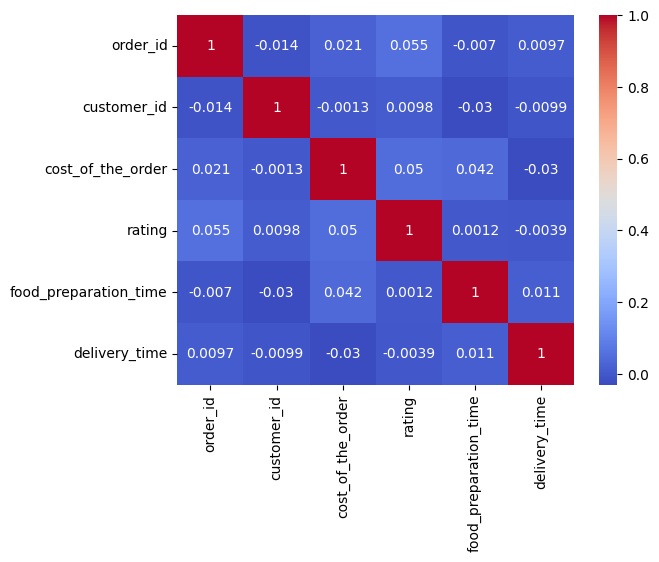

In [14]:
df['rating'] = df['rating'].replace('Not given', 0)
df['rating'] = df['rating'].astype(int)
df.head()

corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

It turns out that there is no real correlation except of the light negative correlation between delivery time and rating, which could be because we interpret the "not given" values as 0. We continue the analysis.

Lets try another combination. delivery time and weekday.


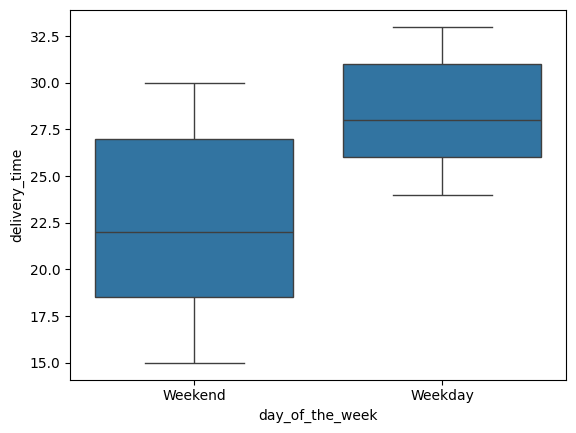

In [15]:
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.show()

It turns out that the delivery time is longer on weekdays. Are there may be more orders during the week?

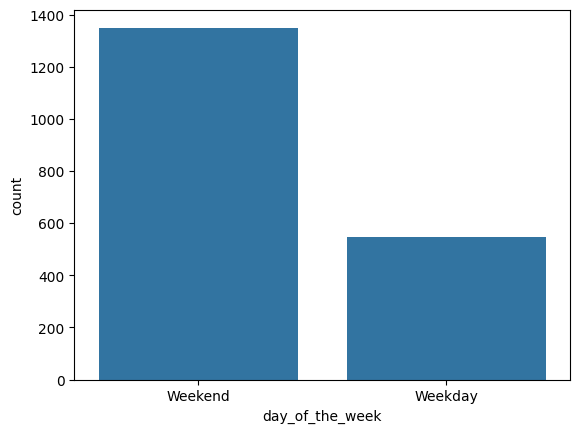

In [16]:
sns.countplot(x='day_of_the_week', data=df)
plt.show()

During the weekend there are more orders, there must be another reason for the longer delivery time.
As next I will compare the data preparation_time and weekday.

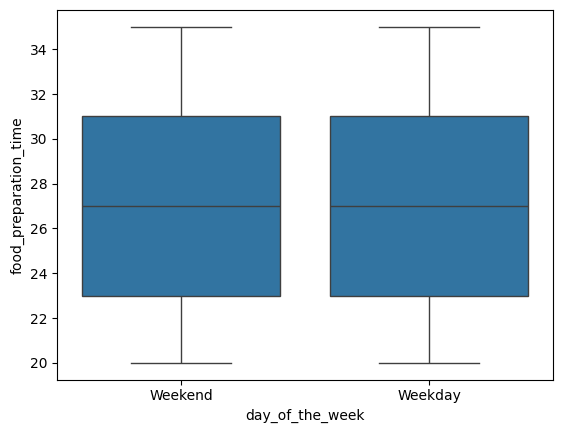

In [17]:
sns.boxplot(x='day_of_the_week', y='food_preparation_time', data=df)
plt.show()

It seems like the preparation time is similar. So the restaurants are prapring the food equally fast, but the delivery takes longer on weekdays.

How about cusine type and preparation time.

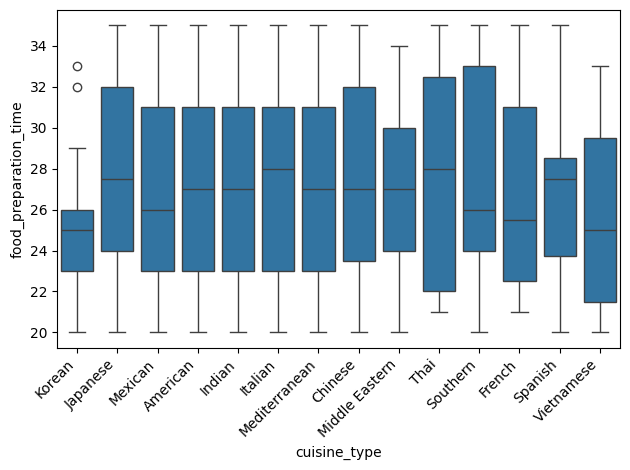

In [18]:
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [19]:
good_rating = df.groupby('restaurant_name')['rating'].sum()
rating_average = df.groupby('restaurant_name')['rating'].mean()


condition = (good_rating > 50) & (rating_average > 4)
restaurants_fulfilling_criteria = good_rating.index[condition]
print(restaurants_fulfilling_criteria)

merged = pd.merge(good_rating, rating_average, on='restaurant_name', how='inner')
filtered = merged[(merged['rating_y'] > 4) & (merged['rating_x'] > 50)]
print(filtered)

#print(good_rating[good_rating>50])
#print(rating_average[rating_average>4])

Index([], dtype='object', name='restaurant_name')
Empty DataFrame
Columns: [rating_x, rating_y]
Index: []


#### Observations:

I tried two different ways to find the combination of all restaurants with rating count more than 50 and in the same time rating avergae higher than 4. It turns out there are no restaurants which fulfill both criteria.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [20]:
# Write the code here
revenue = df['cost_of_the_order'].copy()
revenue_1 = revenue[revenue > 20] * 1.25
revenue_2 = revenue[(revenue > 5) &  (revenue <=20)]  * 1.15
print(revenue_1.sum() + revenue_2.sum())

37438.382999999994


#### Observations:

This is the revenue the company is acchieving 37438$.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [21]:
# Write the code here
total_time = df['delivery_time']+df['food_preparation_time']
(total_time>60).sum()/len(total_time)*100

np.float64(10.537407797681771)

#### Observations:
10% of all orders take longer than 60 minutes in total.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [22]:
# Write the code here
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
During the weekend the dellivery takes longer.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

 The average food preparation time is 27.37 minutes, and the average delivery time is 24.16 minutes.

Delivery times are longer on weekdays (28.34 minutes) compared to weekends (22.47 minutes).

Approximately 10.5% of all orders take more than 60 minutes from the time the order is placed to delivery.

 No restaurants currently meet the criteria for the promotional offer (rating count > 50 AND average rating > 4)

 Shake Shack is the most frequently ordered restaurant, significantly outperforming others.

 In the data more than 30% of the ratings per order are missing. the data is necessary to make further conclusions.

### Recommendations:
Implement small discounts for customers to rate their orders. This will provide more feedback for restaurant evaluation and business improvement.

Change the criteria for promotional offers. The current criteria seems to be too stringent, as no restaurants qualified.

Optimize Weekday Deliveries: Investigate the reasons for longer delivery times on weekdays. May be hire more drivers on weekdays.

 Identify and analyze the specific factors contributing to the 10.5% of orders that exceed 60 minutes in total delivery time. May be specific restaurants, cuisine types, delivery zones.



---